In [1]:
from sklearn.datasets import fetch_openml

freq = fetch_openml(data_id=41214, as_frame=True, parser='auto').frame  # freMTPL2freq
sev = fetch_openml(data_id=41215, as_frame=True, parser='auto').frame   # freMTPL2sev

In [2]:
print(freq.shape)
print(sev.shape)
freq.head()

(678013, 12)
(26639, 2)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


In [4]:
import pandas as pd

# Step 1：讀取資料
df = freq
df2 = sev

# Step 2：把理賠資料（sev）依 IDpol 聚合成一張保單一列，再合併回 freq
sev_agg = df2.groupby('IDpol')['ClaimAmount'].sum().reset_index()
df_merged = pd.merge(df, sev_agg, on='IDpol', how='left')

# Step 3：資料清理
# 3a. 沒出險的保單 ClaimAmount 是 NaN，補成 0
df_merged['ClaimAmount'] = df_merged['ClaimAmount'].fillna(0)

# 3b. Exposure 理論上一年最多 1，超過的是資料錯誤，壓到 1
df_merged['Exposure'] = df_merged['Exposure'].clip(upper=1)

# 3c. ClaimNb 極端值（8、9、11、16 次理賠）壓到 4，避免主導 Poisson 模型
df_merged['ClaimNb'] = df_merged['ClaimNb'].clip(upper=4)

# 3d. ClaimAmount 極端巨額理賠（最大到 407 萬）壓到 99.99% 分位數，避免主導 Gamma 模型
df_merged['ClaimAmount'] = df_merged['ClaimAmount'].clip(upper=65429)

In [5]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

# Step 4：切分訓練集/測試集
train, test = train_test_split(df_merged, test_size=0.2, random_state=1)

In [6]:
# Step 5：Frequency 模型 — Poisson GLM
freq_model = smf.glm(
    formula="ClaimNb ~ BonusMalus + C(Area) + VehPower + VehAge + DrivAge + C(VehBrand) + C(VehGas) + C(Region)",
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train['Exposure'])
).fit()

print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542368
Model Family:                 Poisson   Df Model:                           41
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1477e+05
Date:                Mon, 13 Jul 2026   Deviance:                   1.7392e+05
Time:                        10:57:42   Pearson chi2:                 1.37e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01083
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4

In [7]:
# Step 6：Severity 模型 — Gamma GLM

# 6a. 篩出有出險的保單（頻率模型用 train 全部保單，這裡只用有出險的）
train_sev = train[(train['ClaimNb'] > 0) & (train['ClaimAmount'] > 0)].copy()

# 6b. 算平均每次理賠金額（總理賠金額 / 理賠次數）
train_sev['AvgClaimAmount'] = train_sev['ClaimAmount'] / train_sev['ClaimNb']

# 6c. Fit Gamma GLM
sev_model = smf.glm(
    formula="AvgClaimAmount ~ BonusMalus + C(Area) + VehPower + VehAge + DrivAge + C(VehBrand) + C(VehGas) + C(Region)",
    data=train_sev,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    var_weights=train_sev['ClaimNb']
).fit()

print(sev_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         AvgClaimAmount   No. Observations:                19998
Model:                            GLM   Df Residuals:                    19956
Model Family:                   Gamma   Df Model:                           41
Link Function:                    Log   Scale:                          5.9277
Method:                          IRLS   Log-Likelihood:            -1.8222e+05
Date:                Mon, 13 Jul 2026   Deviance:                       26352.
Time:                        10:58:04   Pearson chi2:                 1.18e+05
No. Iterations:                    13   Pseudo R-squ. (CS):           0.003834
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7

In [8]:
# Step 7：組合 Pure Premium 並在測試集上預測

test = test.copy()

# freq_model 是用 offset fit 出來的，predict() 時同樣要給 offset
# 回傳值已經是「這張保單的預期理賠次數」，不是單位時間頻率，不用再乘 Exposure
test['pred_claimnb'] = freq_model.predict(test, offset=np.log(test['Exposure']))

# sev_model 預測的是「預期單次理賠金額」
test['pred_sev'] = sev_model.predict(test)

# 組合成 Pure Premium：預期理賠次數 x 預期單次理賠金額 = 這張保單的預期理賠成本
test['pred_pure_premium'] = test['pred_claimnb'] * test['pred_sev']

print(test[['ClaimAmount', 'pred_claimnb', 'pred_sev', 'pred_pure_premium']].describe())

         ClaimAmount   pred_claimnb       pred_sev  pred_pure_premium
count  135603.000000  135603.000000  135603.000000      135603.000000
mean       66.178677       0.053376    1807.425574          98.289824
std       893.330381       0.045374     276.961114          93.915054
min         0.000000       0.000036     576.697088           0.035053
25%         0.000000       0.017262    1623.257657          30.552755
50%         0.000000       0.048121    1787.361553          83.439769
75%         0.000000       0.077619    1968.637775         139.149840
max     65429.000000       2.243010    3468.669250        5976.752729


In [10]:
from sklearn.metrics import mean_poisson_deviance
# ===== Step 8：模型評估 — Poisson Deviance 對比 baseline =====
overall_freq = train['ClaimNb'].sum() / train['Exposure'].sum()
baseline_pred = overall_freq * test['Exposure']

dev_baseline = mean_poisson_deviance(
    y_true=test['ClaimNb'] / test['Exposure'],
    y_pred=baseline_pred / test['Exposure'],
    sample_weight=test['Exposure']
)
dev_glm = mean_poisson_deviance(
    y_true=test['ClaimNb'] / test['Exposure'],
    y_pred=test['pred_claimnb'] / test['Exposure'],
    sample_weight=test['Exposure']
)

print(f"Baseline Poisson deviance: {dev_baseline:.4f}")
print(f"GLM 模型 Poisson deviance: {dev_glm:.4f}")
print(f"Deviance 下降幅度: {(1 - dev_glm/dev_baseline)*100:.1f}%")

Baseline Poisson deviance: 0.6157
GLM 模型 Poisson deviance: 0.5976
Deviance 下降幅度: 2.9%


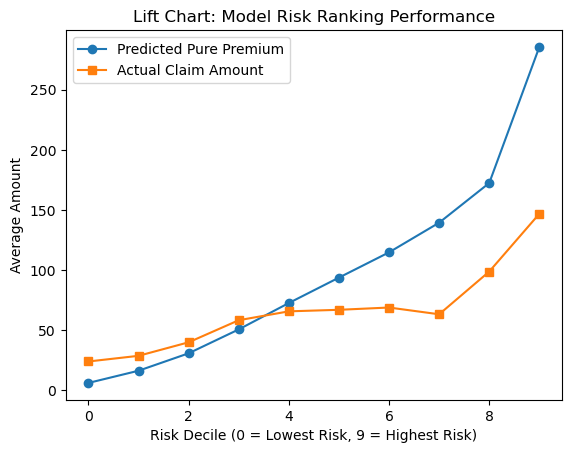

In [18]:
import matplotlib.pyplot as plt

# Step 9: Lift Chart — 驗證模型排序風險的能力

# 9a. 依模型預測的 Pure Premium 分成 10 等分
test['decile'] = pd.qcut(test['pred_pure_premium'], 10, labels=False)

# 9b. 每一組分別算「模型預測平均值」跟「實際理賠平均值」
lift = test.groupby('decile')[['pred_pure_premium', 'ClaimAmount']].mean()

# 9c. 畫圖比較兩條線的走勢
plt.plot(lift.index, lift['pred_pure_premium'], marker='o', label='Predicted Pure Premium')
plt.plot(lift.index, lift['ClaimAmount'], marker='s', label='Actual Claim Amount')
plt.xlabel('Risk Decile (0 = Lowest Risk, 9 = Highest Risk)')
plt.ylabel('Average Amount')
plt.title('Lift Chart: Model Risk Ranking Performance')
plt.legend()
plt.show()